kornia provides the LoFTR deep matcher.

In [ ]:
!pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 131.0 MB/s eta 0:00:00


In [ ]:
!pip install kornia_moons

The image stitching system uses deep learning for feature matching with the model LoFTR.

Deep learning (LoFTR) is used to accurately detect matching points between images, while traditional computer vision techniques handle image alignment and panorama creation.

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import kornia as K
import kornia.feature as KF

In [ ]:
def resize_for_stitching(img, max_dim=800):
    # Get height and width of the image
    h, w = img.shape[:2]

    # Calculate scaling factor based on the largest dimension
    scale = max_dim / max(h, w)

    # If the image is larger than max_dim, resize it
    if scale < 1:
        # Resize image while keeping the same aspect ratio
        img = cv2.resize(img, (int(w*scale), int(h*scale)))

    # Return the resized (or original) image
    return img

In [ ]:
import cv2
import matplotlib.pyplot as plt

# List to store the original images
images = []

# List to store grayscale versions of the images
gray_images = []

# Loop through image files (image001.png, image002.png)
for i in range(1, 3):
    # Create the image file path
    path = f"/content/image00{i}.png"

    # Read the image from the path
    img = cv2.imread(path)

    # Resize the image if it is too large
    img = resize_for_stitching(img)

    # Convert the image to grayscale (needed for feature detection)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Store the original image in the list
    images.append(img)

    # Store the grayscale image in another list
    gray_images.append(gray)

# Print how many images were successfully loaded
print("Loaded images:", len(images))

Loaded images: 2


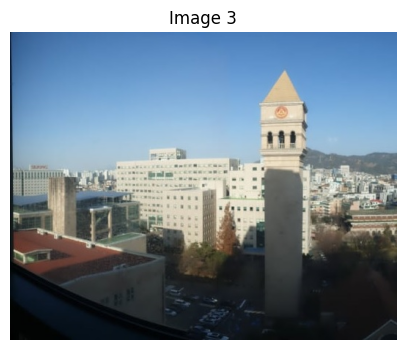

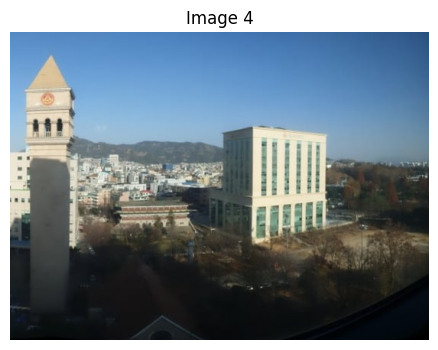

In [ ]:
for i, img in enumerate(images):
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+3}")
    plt.axis("off")
    plt.show()

In [ ]:
# Load the LoFTR feature matching model with pretrained weights
matcher = KF.LoFTR(pretrained='outdoor').eval()

In [ ]:
def stitch_pair(img1, img2):

    # Convert both images to grayscale
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Convert images to PyTorch tensors and normalize pixel values (0–1)
    # [None, None] adds batch and channel dimensions required by LoFTR
    timg1 = torch.from_numpy(img1_gray/255.).float()[None,None]
    timg2 = torch.from_numpy(img2_gray/255.).float()[None,None]

    # Create input dictionary for LoFTR
    input_dict = {
        "image0": timg1,
        "image1": timg2
    }

    # Run the matcher without computing gradients (inference mode)
    with torch.no_grad():
        correspondences = matcher(input_dict)

    # Extract matched keypoints from both images
    mkpts0 = correspondences['keypoints0'].cpu().numpy()
    mkpts1 = correspondences['keypoints1'].cpu().numpy()

    # Homography requires at least 4 matching points
    if len(mkpts0) < 4:
        print("Not enough matches:", len(mkpts0))
        return img1

    # Estimate homography matrix using RANSAC to remove bad matches
    H, mask = cv2.findHomography(mkpts1, mkpts0, cv2.RANSAC, 5.0)

    # Get height and width of the first image
    height, width = img1.shape[:2]

    # Warp the second image to align with the first image
    warped_img2 = cv2.warpPerspective(img2, H, (width*2, height))

    # Copy the warped image
    stitched = warped_img2.copy()

    # Place the first image on the left side of the stitched result
    stitched[0:height,0:width] = img1

    # Return the stitched panorama
    return stitched

In [ ]:
# Start the panorama using the first image
panorama = images[0]

# Loop through the remaining images
for i in range(1, len(images)):

    # Print which image is currently being stitched
    print(f"Stitching image {i+2} with panorama (images 0-{i+1})")

    # Stitch the current image with the existing panorama
    new_panorama = stitch_pair(panorama, images[i])

    # If stitching failed (not enough matches)
    if new_panorama is None:
        print(f"Skipping image {i+2} due to insufficient matches.")
    else:
        # Update the panorama with the newly stitched result
        panorama = new_panorama

    # Resize the panorama to limit its size and prevent GPU/RAM overflow
    panorama = resize_for_stitching(panorama, 800)

Stitching image 3 with panorama (images 0-2)


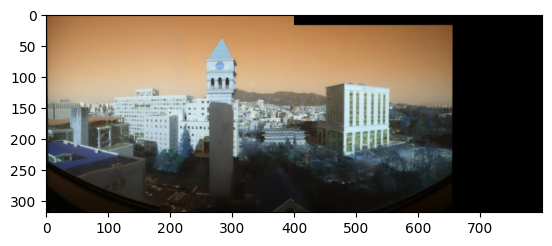

In [ ]:
plt.imshow(panorama)